<a href="https://colab.research.google.com/github/azrasm/waste-classification/blob/main/GUI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projekat LV9 - **Grafički korisnički interfejs**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Saving flase.PNG to flase.PNG
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


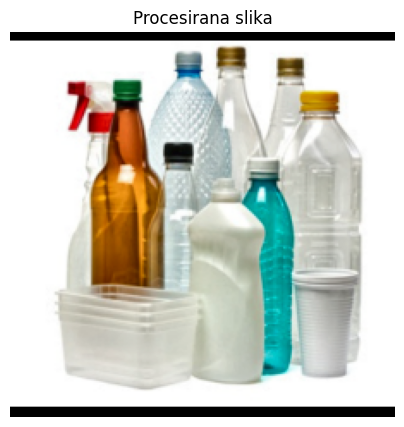

Kategorija otpada: Recyclable
Vjerovatnoća: 0.9292


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/POOS projekat/resnet50_waste_classifier_best.keras"
)

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

#Učitavanje slike
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise ValueError("Slika nije uspješno učitana.")

#BGR → RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

#CLAHE izjednačavanje kontrasta
lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
cl = clahe.apply(l)
img_clahe = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)
img_enhanced = img_clahe.copy()

#Resize + padding
target_h, target_w = 224, 224
h, w = img_enhanced.shape[:2]
scale = min(target_h / h, target_w / w)
new_h, new_w = int(h * scale), int(w * scale)
resized = cv2.resize(img_enhanced, (new_w, new_h), interpolation=cv2.INTER_AREA)
padded = np.zeros((target_h, target_w, 3), dtype=np.uint8)
y_offset = (target_h - new_h) // 2
x_offset = (target_w - new_w) // 2
padded[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

#Normalizacija na [0,1]
processed_img = padded.astype(np.float32) / 255.0

input_tensor = np.expand_dims(processed_img, axis=0)

#Predikcija
prediction = model.predict(input_tensor)

#Za sigmoid binary model
predicted_class = 1 if prediction[0][0] >= 0.5 else 0
confidence = prediction[0][0] if predicted_class == 1 else 1 - prediction[0][0]

class_names = ["Organic", "Recyclable"]

#Prikaz slike i rezultata
plt.figure(figsize=(5, 5))
plt.imshow(processed_img)
plt.axis("off")
plt.title("Procesirana slika")
plt.show()

print(f"Kategorija otpada: {class_names[predicted_class]}")
print(f"Vjerovatnoća: {confidence:.4f}")

In [ ]:
!pip install gradio

import cv2
import numpy as np
import tensorflow as tf
import gradio as gr

#Učitavanje modela
model_path = "/content/drive/MyDrive/POOS projekat/resnet50_waste_classifier_best.keras"
model = tf.keras.models.load_model(model_path)

class_names = ["Organic", "Recyclable"]

#Preprocessing
def preprocess(image):
    #image dolazi kao numpy array (H, W, 3) u RGB formatu od Gradio
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image.shape[2]==3 else image

    #CLAHE
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    img_clahe = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)

    #Resize + padding
    target_h, target_w = 224, 224
    h, w = img_clahe.shape[:2]
    scale = min(target_h / h, target_w / w)
    new_h, new_w = int(h * scale), int(w * scale)
    resized = cv2.resize(img_clahe, (new_w, new_h), interpolation=cv2.INTER_AREA)
    padded = np.zeros((target_h, target_w, 3), dtype=np.uint8)
    y_offset = (target_h - new_h) // 2
    x_offset = (target_w - new_w) // 2
    padded[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

    #Normalizacija
    processed_img = padded.astype(np.float32) / 255.0
    return processed_img

#Funkcija za predikciju
def classify_image(image):
    processed_img = preprocess(image)
    input_tensor = np.expand_dims(processed_img, axis=0)
    prediction = model.predict(input_tensor)[0][0]

    predicted_class = 1 if prediction >= 0.5 else 0
    confidence = prediction if predicted_class == 1 else 1 - prediction

    #Vjerovatnoće obje klase
    probs = {
        class_names[0]: float(1 - prediction),
        class_names[1]: float(prediction)
    }

    return probs

#Gradio Interface
interface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(num_top_classes=2),
    live=True,
    title="Waste Classifier",
    description="Upload a waste image and the model will predict if it is Recyclable or Organic."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://39a13b4ba6f4847178.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
